# GeoTIGER: five-address Washington, DC demo

This compact example uses a five-row local address table as the reference dataset and geocodes a five-row input table entirely in memory. No geocoding API, basemap, or network request is used. It produces both an offline static Matplotlib map and an offline Folium map.

## 1. Create a tiny local reference table

In a real project this table can come from a parcel or address-point file. The coordinates below are local reference coordinates; GeoTIGER normalizes the address fields and stores them in its common prepared schema.

In [1]:
import pandas as pd
from IPython.display import display

from geotiger import (
    Geocoder,
    GeoTIGERStore,
    prepare_addresses,
    matches_map,
    matches_static_map,
)

reference = pd.DataFrame([
    {'address_id': 'white-house', 'address': '1600 Pennsylvania Ave NW', 'city': 'Washington', 'state': 'DC', 'zip': '20500', 'lon': -77.0365, 'lat': 38.8977},
    {'address_id': 'lincoln-memorial', 'address': '1 Lincoln Memorial Cir NW', 'city': 'Washington', 'state': 'DC', 'zip': '20037', 'lon': -77.0502, 'lat': 38.8893},
    {'address_id': 'capitol-hill', 'address': '700 Pennsylvania Ave SE', 'city': 'Washington', 'state': 'DC', 'zip': '20003', 'lon': -76.9947, 'lat': 38.8871},
    {'address_id': 'southwest', 'address': '400 4th St SW', 'city': 'Washington', 'state': 'DC', 'zip': '20024', 'lon': -77.0163, 'lat': 38.8840},
    {'address_id': 'downtown', 'address': '1200 New York Ave NW', 'city': 'Washington', 'state': 'DC', 'zip': '20005', 'lon': -77.0286, 'lat': 38.9008},
])
prepared = prepare_addresses(reference, source='dc-local-addresses')
print(f'Prepared {len(prepared)} local reference rows')
display(prepared[['address_id', 'house_number', 'street_norm', 'city', 'state', 'zip5', 'latitude', 'longitude']])

Prepared 5 local reference rows


,address_id,house_number,street_norm,city,state,zip5,latitude,longitude
0,dc-local-addresses:white-house:0,1600,PENNSYLVANIA AVE NW,WASHINGTON,DC,20500,38.8977,-77.0365
1,dc-local-addresses:lincoln-memorial:1,1,LINCOLN MEMORIAL CIR NW,WASHINGTON,DC,20037,38.8893,-77.0502
2,dc-local-addresses:capitol-hill:2,700,PENNSYLVANIA AVE SE,WASHINGTON,DC,20003,38.8871,-76.9947
3,dc-local-addresses:southwest:3,400,4TH ST SW,WASHINGTON,DC,20024,38.8840,-77.0163
4,dc-local-addresses:downtown:4,1200,NEW YORK AVE NW,WASHINGTON,DC,20005,38.9008,-77.0286


## 2. Geocode a five-row input table locally

The input uses expanded street suffixes to demonstrate normalization (`Avenue` to `AVE`, `Circle` to `CIR`, and `Street` to `ST`).

In [2]:
inputs = pd.DataFrame([
    {'record_id': 1, 'address': '1600 Pennsylvania Avenue NW', 'city': 'Washington', 'state': 'DC', 'zip': '20500'},
    {'record_id': 2, 'address': '1 Lincoln Memorial Circle NW', 'city': 'Washington', 'state': 'DC', 'zip': '20037'},
    {'record_id': 3, 'address': '700 Pennsylvania Avenue SE', 'city': 'Washington', 'state': 'DC', 'zip': '20003'},
    {'record_id': 4, 'address': '400 4th Street SW', 'city': 'Washington', 'state': 'DC', 'zip': '20024'},
    {'record_id': 5, 'address': '1200 New York Avenue NW', 'city': 'Washington', 'state': 'DC', 'zip': '20005'},
])
store = GeoTIGERStore(':memory:', threads=1)
store.create()
store.ingest_candidates(prepared)
result = Geocoder(store).geocode(inputs)
print(result.timings.to_dict())
display(result.matches[['record_id', 'address', 'matched_address_id', 'score', 'match_status', 'match_latitude', 'match_longitude']])

{'input_count': 5, 'candidate_count': 5, 'lookup_hit_count': 0, 'history_cache_hit_count': 0, 'matched_count': 5, 'review_count': 0, 'unmatched_count': 0, 'parse_seconds': 0.003311, 'lookup_seconds': 0.015373, 'history_cache_seconds': 0.013792, 'candidate_query_seconds': 0.028453, 'scoring_seconds': 0.016474, 'aggregation_seconds': 0.024134, 'total_seconds': 0.109637, 'throughput_per_second': 45.605, 'duckdb_threads': 1, 'python': '3.12.12', 'platform': 'Windows-10-10.0.19045-SP0'}


,record_id,address,matched_address_id,score,match_status,match_latitude,match_longitude
0,1,1600 Pennsylvania Avenue NW,dc-local-addresses:white-house:0,100.0,matched,38.8977,-77.0365
1,2,1 Lincoln Memorial Circle NW,dc-local-addresses:lincoln-memorial:1,100.0,matched,38.8893,-77.0502
2,3,700 Pennsylvania Avenue SE,dc-local-addresses:capitol-hill:2,100.0,matched,38.8871,-76.9947
3,4,400 4th Street SW,dc-local-addresses:southwest:3,100.0,matched,38.8840,-77.0163
4,5,1200 New York Avenue NW,dc-local-addresses:downtown:4,100.0,matched,38.9008,-77.0286


## 3. Two offline map outputs

The static map is useful for reports and notebooks that should not depend on JavaScript tiles. The Folium map is interactive but also has no basemap configured, so it remains local-only when viewed.

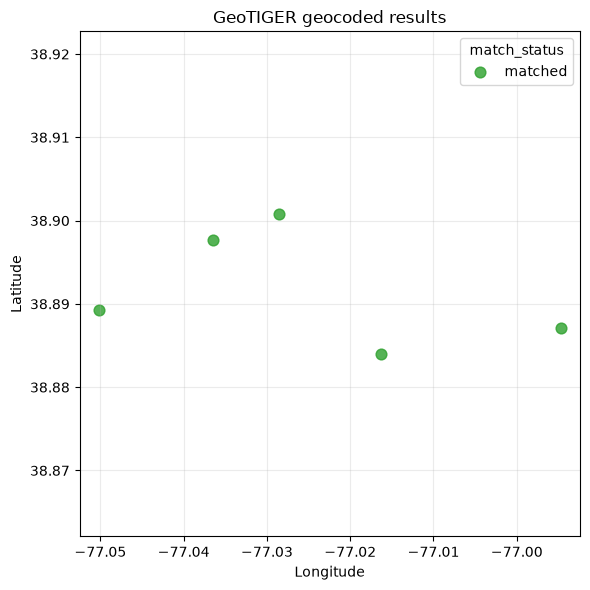

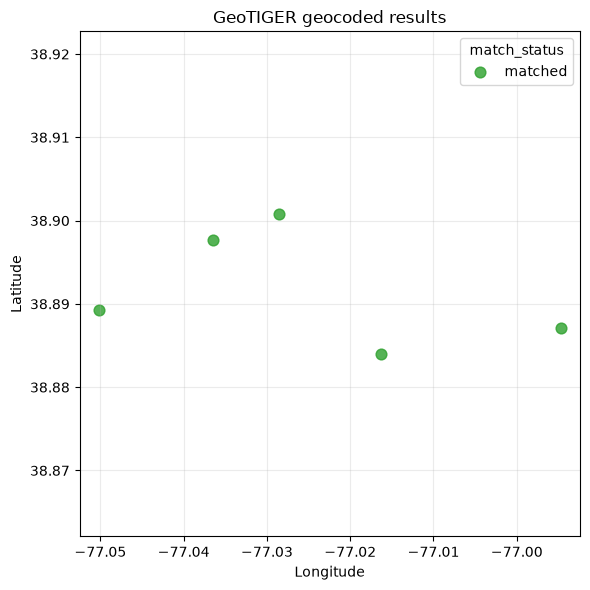

In [3]:
static_axes = matches_static_map(result.matches, figsize=(6, 6), point_size=60)
static_axes.figure.tight_layout()
static_axes.figure

In [4]:
interactive_map = matches_map(result.matches, tiles=None, zoom_start=12)
interactive_map

The five points are reference coordinates supplied by the local table. For production use, replace `reference` with a locally stored parcel/address-point dataset or a locally prepared TIGER range database.